In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import math

import numpy as np
import pandas as pd

import os
import os.path as osp

import matplotlib.pyplot as plt

from datasets import load_dataset, load_from_disk, ClassLabel, DatasetDict, Dataset
import pandas as pd

import re


In [2]:
pd.set_option("display.max_colwidth", 200)

In [3]:
def compute_stats_df(df, text_cols=("kor", "en")):
    rows = []
    for col in text_cols:
        lengths = df[col].astype(str).str.len().values  # 문자 길이 기준
        # df[col] : col 열을 Series 클래스로
        # .astype(str) : 가져온 열의 값들을 str로 강제 변환 (숫자, NaN 등 str이 아닌 값들이 섞여 있으면 .str을 쓸 수 없으므로 미리 강제 변환)
        # .str : Series의 .str 접근자는 python built-in str 함수들을 Series 안의 모든 원소에 각각 적용 가능하게 해준다
        # # The .str accessor in pandas provides vectorized string functions, 
        # # allowing you to apply Python's built-in string methods to every element in a Series (or Index) at once, without explicit looping. 
        # # This accessor is only available for Series that hold string or object data types.
        # .str.len() : .str 뒤에 .len()을 붙여 Series의 모든 str 원소에 len() 적용해 각 원소의 문자 길이를 얻는다 ==> 그러한 문자 길이를 담은 새 Series 반환
        # .values : Series를 numpy의 ndarray로 변환

        arr = lengths
        rows.append({
            "column": col,
            "num_examples": len(df),
            "avg_len": float(arr.mean()),
            "min_len": int(arr.min()),
            "max_len": int(arr.max()),
            "p50_len": int(np.percentile(arr, 50)),
            "p90_len": int(np.percentile(arr, 90)),
            "p95_len": int(np.percentile(arr, 95)),
            "p99_len": int(np.percentile(arr, 99)),
        })

        print(f"{col} max: ", arr.argmax(), "번째 - ", df["kor"][arr.argmax()], " == " , df["en"][arr.argmax()])
        print(f"{col} min: ", arr.argmin(), "번째 - ",df["kor"][arr.argmin()], " == " , df["en"][arr.argmin()])
    return pd.DataFrame(rows)


In [4]:
def show_en_histo(df):
    # 영어 문장 길이 (문자 길이 기준)
    en_len = df["en"].astype(str).str.len().values

    # 너무 큰 값이 있으면 (예: 5000자 이상) 로그스케일이나 클리핑을 고려할 수도 있음
    # en_len = np.clip(en_len, 0, 3000)

    plt.figure(figsize=(10, 6))
    plt.hist(en_len, bins=100, color="steelblue", edgecolor="black")
    plt.xlabel("English sentence length (characters)")
    plt.ylabel("Count")
    plt.title("Histogram of English sentence lengths")
    plt.yscale("log")  # 긴 꼬리가 있을 때는 로그 스케일이 보기 좋음
    plt.tight_layout()
    plt.show()

In [5]:
def show_kor_histo(df):
    # 한국어 문장 길이 (문자 길이 기준)
    kor_len = df["kor"].astype(str).str.len().values

    # 너무 큰 값이 있으면 (예: 5000자 이상) 로그스케일이나 클리핑을 고려할 수도 있음
    # en_len = np.clip(en_len, 0, 3000)

    plt.figure(figsize=(10, 6))
    plt.hist(kor_len, bins=100, color="steelblue", edgecolor="black")
    plt.xlabel("Korean sentence length (characters)")
    plt.ylabel("Count")
    plt.title("Histogram of Korean sentence lengths")
    plt.yscale("log")  # 긴 꼬리가 있을 때는 로그 스케일이 보기 좋음
    plt.tight_layout()
    plt.show()

# 데이터셋 로드

In [ ]:
ds = load_dataset("nayohan/aihub-en-ko-translation-12m")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['domain', 'subdomain', 'style', 'target', 'source', 'target_text', 'source_text'],
        num_rows: 11895711
    })
})


# 데이터셋 분석

In [3]:
unique_classes = ds.unique('domain')  
print(unique_classes)
print(f"==>> len(unique_classes): {len(unique_classes['train'])}")

{'train': ['일상생활', '해외고객과의채팅', '해외영업', '경제', '기술과학', '기후', '세계', '정치', '교양', '다큐', '연예공연', '영화드라마', '예능오락', '인터뷰', '기타', '다큐교양', '01000', '02000', '03000', '10110', '10121', '10122', '10129', '10210', '10220', '10300', '10400', '10500', '10610', '10620', '10712', '10713', '10720', '10730', '10742', '10743', '10749', '10750', '10791', '10792', '10795', '10796', '10797', '10799', '10801', '10802', '11110', '11120', '11200', '12000', '13103', '13104', '13109', '13213', '13219', '13221', '13224', '13229', '13400', '13920', '13992', '13994', '13999', '14120', '14191', '14192', '14194', '14199', '14411', '14419', '14491', '14499', '15129', '15211', '15219', '15220', '16101', '16102', '16103', '16211', '16212', '16221', '16229', '16230', '16300', '17110', '17120', '17220', '17901', '17902', '17909', '18110', '18120', '18200', '19210', '19221', '19229', '20111', '20119', '20121', '20129', '20131', '20132', '20201', '20202', '20203', '20311', '20312', '20313', '20321', '20322', '20411', '20413'

In [4]:
# 데이터셋 전체를 pandas로 바꾸지 않고, 데이터셋 형식만 변경하여 확인 (메모리 절약)
ds.set_format(type="pandas")
df = ds['train']
print(df['domain'].value_counts())


domain
None                             1501772
해외영업                             1260367
일상생활                              899757
경제                                548114
해외고객과의채팅                          540221
                                  ...   
역사/근현대|문화·교육/언론·출판|문화유산/기록 유산          1
역사/근현대|종교/기독교|성씨·인물/근현대인물              1
역사/근현대|정치·경제·사회/경제 산업                  1
역사/근현대|인물/근현대 인물                       1
정치·경제·사회/경제·산업|문화·교육/문화·예술             1
Name: count, Length: 664, dtype: int64


In [5]:
print(df['style'].value_counts())

style
문어체     5923098
구어체     3119332
None    2393282
특허       359999
대화체      100000
Name: count, dtype: int64


In [6]:
print(df['subdomain'].value_counts())

subdomain
None                  3915439
도소매유통                 1025979
음식                     314915
여행                     291357
법률연구                   244865
                       ...   
농산물                         3
인물 사진 및 행사용 영상 촬영업          2
식품일반                        2
보이스7                        2
건강식품류                       1
Name: count, Length: 657, dtype: int64


In [7]:

# 자료 확인 후 ds 원래 포맷으로 복구
ds.reset_format()

TODO: 데이터셋 처음 상태에서 다양한 분석 결과 추가하기

# 대분류 추가

In [8]:
count = 0

def map_domain(raw_domain: str) -> str:
    if raw_domain is None:
        return "기타"

    d = raw_domain

    # 1) 명시적인 매핑
    if d in ["일상생활", "구어체_대화체", "해외고객과의채팅", "해외영업"]:
        return "일상/대화"

    if d in ["뉴스문어체", "지자체웹사이트 문어체", "가정통신문", "스포츠"]:
        return "뉴스/시사"

    if d in ["교양", "다큐", "다큐교양", "연예공연", "영화드라마", "예능오락", "인터뷰", "기타", # 방송콘텐츠 데이터셋에 기타 분류가 있음
             "문화문어체", 
             "문화", "문화·예술", "문화·교육", "문화재", "민속", "생활·민속",
             "문화유산", "역사", "역사/근현대", "역사/전통 시대",
             "구비 전승·언어·문학", "성씨·인물",
             "관광", "예술", "향토문화/음식", "종교", "지리",
             "정치·경제·사회", "정치∙경제∙사회", # 종류가 두가지?
             "정치·경제·산업/경제·산업|역사/근현대", "한국국제문화교류진흥원"]:
        return "문화/예술/역사"
    

    if d in ["경제", "세계", "정치", "기후", "기술과학", # 기술과학 분야 한-영 번역 병렬 말뭉치 데이터
             "글로벌동향정보", "연구평가정보", "위해식품정보", "법제도정보", # 식품 전문 분야 데이터
             "IT/기술", "ICT", "컴퓨터과학", "정보-통신",
             "공학", "전기", "전자", "재료", "재료과학",
             "수학", "물리학", "미생물학", "화학", "생명과학", "생물학 생화학",
             "환경과 생태학", "농학", "농림수산식품", "기계",
             "사회", "사회과학", "전문분야 문어체", "교육"]:
        return "과학/기술/학술자료"

    if d in ["의료/보건", "보건의료", "의학", "의약학", "의약학", "약리학 독성학"]:
        return "의학/보건"

    if d in ["법률", "대법원판례", "조례문어체", "교통"]:
        return "법률/행정"

    if d in ["금융/증시"]:
        return "금융/경제"

    # 2) 패턴 기반 매핑 (복잡한 문자열들)
    if d.startswith("문화·교육") or d.startswith("문화유산") or d.startswith("생활·민속"):
        return "문화/예술/역사"
    if d.startswith("역사/"):
        return "문화/예술/역사"
    if d.startswith("종교/"):
        return "문화/예술/역사"
    if d.startswith("지리/"):
        return "문화/예술/역사"
    if d.startswith("정치·경제·사회"):
        return "문화/예술/역사"
    if "의료" in d or "의학" in d or "보건" in d:
        return "의학/보건"
    
    # 특허
    if d.isdigit():
        return "특허"
    
    if d in ["H", "K"]:
        return "특허"

    # 3) 그 밖의 코드/기타 값
    if d in ["None"]:
        return "기타"

    # 조건에서 벗어난 경우의 수 카운트
    global count 
    count += 1
    print(d)
    # 기본값
    return "기타"


In [9]:
def map_domain_batch(batch):
    batch["super_domain"] = [map_domain(d) for d in batch["domain"]]
    return batch

In [10]:
ds = ds.map(map_domain_batch, batched=True)

In [11]:
ds.set_format(type="pandas")
df = ds['train']

In [12]:
print(df['super_domain'].value_counts())

super_domain
과학/기술/학술자료    3822044
일상/대화         2719332
기타            1501772
문화/예술/역사      1346542
의학/보건          720037
법률/행정          626520
뉴스/시사          619465
특허             359999
금융/경제          180000
Name: count, dtype: int64


In [13]:

# 자료 확인 후 ds 원래 포맷으로 복구
ds.reset_format()

# 기타 대분류 1501772개 == AI HUB 한국어-영어 번역(병렬) 말뭉치 데이터셋

In [14]:
df = ds['train'].to_pandas()

In [15]:
df_etc = df[df['super_domain'] == "기타"]

In [16]:
df_etc["domain"].value_counts()

domain
None    1501772
Name: count, dtype: int64

In [17]:
df_etc["subdomain"].value_counts()

subdomain
None    1501772
Name: count, dtype: int64

In [18]:
df_etc["style"].value_counts()

style
문어체    1001772
구어체     400000
대화체     100000
Name: count, dtype: int64

In [19]:
df_aihub = pd.read_csv("data.csv")
len(df_aihub)

1602418

In [ ]:
merged = df_etc.merge(
    df_aihub.rename(columns={"en": "source_text", "kor": "target_text"}),
    on=["source_text", "target_text"],
    how="outer",
    indicator=True
)

print("df_etc에도 df_aihub에도 있는 행들:")
print(merged[merged["_merge"] == "both"].shape[0])

print("df_etc에만 있는 행들:")
print(merged[merged["_merge"] == "left_only"].shape[0])

print("df_aihub에만 있는 행들:")
print(merged[merged["_merge"] == "right_only"].shape[0])

df_etc에서 df_aihub에도 있는 행들:
1504288
df_etc에만 있는 행들:
0
df_aihub에만 있는 행들:
98174


# df_etc 길이는 1501722인데 both가 1504288로 더 큼 (2516 차이) => 중복 문장 쌍 개수 확인

In [21]:
# df_aihub에서 중복된 (en, kor) 쌍이 몇 개인지
pairs_aihub = df_aihub[["en", "kor"]].value_counts()
duplicated_pairs = pairs_aihub[pairs_aihub > 1]
print(f"df_aihub 중복 쌍 개수: {len(duplicated_pairs)}")
print(f"중복 쌍으로 인한 추가 행 수: {duplicated_pairs.sum() - len(duplicated_pairs)}")


df_aihub 중복 쌍 개수: 2494
중복 쌍으로 인한 추가 행 수: 2494


In [22]:
# df_etc에서 중복된 (en, kor) 쌍이 몇 개인지
pairs_etc = df_etc[["source_text", "target_text"]].value_counts()
duplicated_pairs = pairs_etc[pairs_etc > 1]
print(f"df_etc 중복 쌍 개수: {len(duplicated_pairs)}")
print(f"중복 쌍으로 인한 추가 행 수: {duplicated_pairs.sum() - len(duplicated_pairs)}")


df_etc 중복 쌍 개수: 22
중복 쌍으로 인한 추가 행 수: 22


2494 + 22 == 2516 ==> 확인 완료

# 중복 제거 후 확인

In [23]:
# df_etc에서 (source_text, target_text) 쌍 기준으로 중복 제거
df_etc_unique = df_etc.drop_duplicates(subset=["source_text", "target_text"])
print(f"==>> len(df_etc_unique): {len(df_etc_unique)}")

# df_aihub에서 (en, kor) 쌍 기준으로 중복 제거
df_aihub_unique = df_aihub.drop_duplicates(subset=["en", "kor"])
print(f"==>> len(df_aihub_unique): {len(df_aihub_unique)}")



==>> len(df_etc_unique): 1501750
==>> len(df_aihub_unique): 1599924


In [ ]:
merged_unique = df_etc_unique.merge(
    df_aihub_unique.rename(columns={"en": "source_text", "kor": "target_text"}),
    on=["source_text", "target_text"],
    how="outer",
    indicator=True
)

print("df_etc_unique에도 df_aihub_unique에도 있는 행들:")
print(merged_unique[merged_unique["_merge"] == "both"].shape[0])

print("df_etc_unique에만 있는 행들:")
print(merged_unique[merged_unique["_merge"] == "left_only"].shape[0])

print("df_aihub_unique에만 있는 행들:")
print(merged_unique[merged_unique["_merge"] == "right_only"].shape[0])

df_etc_unique에서 df_aihub_unique에도 있는 행들:
1501750
df_etc_unique에만 있는 행들:
0
df_aihub_unique에만 있는 행들:
98174


# AI HUB 한국어-영어 번역(병렬) 말뭉치 데이터셋 (1602418) - 기타 (1501772) == 100646
- 100646은 AI HUB 한국어-영어 번역(병렬) 말뭉치 데이터셋의 문어체_한국문화(cat=3) 데이터 개수와 동일
- 문어체_한국문화 분류의 데이터가 12m 데이터셋의 기타 제외 부분에 포함되어 있는지 확인하기

In [25]:
df_aihub_3 = df_aihub[df_aihub["cat"] == 3]
print(f"==>> len(df_aihub_3): {len(df_aihub_3)}")

==>> len(df_aihub_3): 100646


In [26]:
df_not_etc =  df[df['super_domain'] != "기타"]
print(f"==>> len(df_not_etc): {len(df_not_etc)}")

==>> len(df_not_etc): 10393939


In [27]:
# df_not_etc에서 (source_text, target_text) 쌍 기준으로 중복 제거
df_not_etc_unique = df_not_etc.drop_duplicates(subset=["source_text", "target_text"])
print(f"==>> len(df_not_etc_unique): {len(df_not_etc_unique)}")

# df_aihub에서 (en, kor) 쌍 기준으로 중복 제거
df_aihub_3_unique = df_aihub_3.drop_duplicates(subset=["en", "kor"])
print(f"==>> len(df_aihub_3_unique): {len(df_aihub_3_unique)}")



==>> len(df_not_etc_unique): 9734537
==>> len(df_aihub_3_unique): 100646


In [ ]:
df_not_etc_unique.to_csv("preprocess/not_etc_unique.csv")

: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import math

import numpy as np
import pandas as pd

import os
import os.path as osp

import matplotlib.pyplot as plt

from datasets import load_dataset, load_from_disk, ClassLabel, DatasetDict, Dataset
import pandas as pd


In [2]:
df_not_etc_unique = pd.read_csv("preprocess/not_etc_unique.csv")
print(f"==>> len(df_not_etc_unique): {len(df_not_etc_unique)}")

/tmp/ipykernel_21740/1068616865.py:1: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_not_etc_unique = pd.read_csv("preprocess/not_etc_unique.csv")


==>> len(df_not_etc_unique): 9734537


In [3]:
df_aihub = pd.read_csv("data.csv")
df_aihub_3 = df_aihub[df_aihub["cat"] == 3]
print(f"==>> len(df_aihub_3): {len(df_aihub_3)}")

==>> len(df_aihub_3): 100646


In [4]:
merged_unique = df_not_etc_unique.merge(
    df_aihub_3.rename(columns={"en": "source_text", "kor": "target_text"}),
    on=["source_text", "target_text"],
    how="outer",
    indicator=True
)

print("df_not_etc_unique에도 df_aihub_3에도 있는 행들:")
print(merged_unique[merged_unique["_merge"] == "both"].shape[0])

print("df_not_etc_unique에만 있는 행들:")
print(merged_unique[merged_unique["_merge"] == "left_only"].shape[0])

print("df_aihub_3에만 있는 행들:")
print(merged_unique[merged_unique["_merge"] == "right_only"].shape[0])

df_not_etc_unique에서 df_aihub_3에도 있는 행들:
100646
df_not_etc_unique에만 있는 행들:
9633891
df_aihub_3에만 있는 행들:
0


In [5]:
both = merged_unique[merged_unique["_merge"] == "both"]
both["super_domain"].value_counts()


super_domain
문화/예술/역사    100158
뉴스/시사          477
법률/행정           11
Name: count, dtype: int64

In [6]:
both["style"].value_counts()

style
문어체    100646
Name: count, dtype: int64

AI HUB 한국어-영어 번역(병렬) 말뭉치 데이터셋의 문어체_한국문화도 12m 데이터셋에 포함되어 있는 것을 확인 가능
12m 데이터셋에 super_domain 기타로 분류되어 있던 다른 분류 데이터들과 다르게 문어체_한국문화 분류의 데이터는 문화/예술/역사, 뉴스/시사, 법률/행정 등으로 분류

# AI HUB 한국어-영어 번역(병렬) 말뭉치 데이터셋에 super_domain과 style 추가

In [2]:
ds_ai = load_dataset("csv", data_files="data.csv",)
ds_ai

DatasetDict({
    train: Dataset({
        features: ['kor', 'en', 'cat'],
        num_rows: 1602418
    })
})

문어체_한국문화(100646개)는 12m 데이터셋에 포함되어 있으므로 필터링

In [3]:
ds_ai = ds_ai.filter(lambda x: x["cat"] != 3)
ds_ai

Filter:   0%|          | 0/1602418 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['kor', 'en', 'cat'],
        num_rows: 1501772
    })
})

In [4]:
# cat_names = ["구어체", "대화체", "문어체_뉴스", "문어체_한국문화", "문어체_조례", "문어체_지자체웹사이트"]

def map_domain(raw_domain) -> str:
    if raw_domain == 0:
        return "일상/대화"
    
    if raw_domain == 1:
        return "일상/대화"
    
    if raw_domain == 2:
        return "뉴스/시사"
    
    if raw_domain == 3:
        return "문화/예술/역사"
    
    if raw_domain == 4:
        return "법률/행정"

    if raw_domain == 5:
        return "뉴스/시사"
    
    return "기타"

def map_style(raw_domain) -> str:
    if raw_domain == 0:
        return "구어체"
    
    if raw_domain == 1:
        # 대화체도 style 구어체로 통일
        return "구어체"
    
    return "문어체"

In [5]:
def map_domain_batch(batch):
    batch["super_domain"] = [map_domain(c) for c in batch["cat"]]
    batch["style"] = [map_style(c) for c in batch["cat"]]
    return batch

In [6]:
ds_ai = ds_ai.map(map_domain_batch, batched=True)
ds_ai

Map:   0%|          | 0/1501772 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['kor', 'en', 'cat', 'super_domain', 'style'],
        num_rows: 1501772
    })
})

In [7]:
ds_ai["train"] = ds_ai["train"].remove_columns("cat")
ds_ai

DatasetDict({
    train: Dataset({
        features: ['kor', 'en', 'super_domain', 'style'],
        num_rows: 1501772
    })
})

In [8]:
ds_ai['train'].to_csv("preprocess/aihub.csv")

Creating CSV from Arrow format:   0%|          | 0/1502 [00:00<?, ?ba/s]

462403017

# 12m 데이터셋과 AI HUB 한국어-영어 번역(병렬) 말뭉치 데이터셋 병합

In [9]:
ds = load_dataset("csv", data_files="preprocess/not_etc_unique.csv",)
ds

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'domain', 'subdomain', 'style', 'target', 'source', 'target_text', 'source_text', 'super_domain'],
        num_rows: 9734537
    })
})

In [10]:
ds["train"] = ds["train"].remove_columns(['Unnamed: 0', 'domain', 'subdomain', 'target', 'source'])
ds

DatasetDict({
    train: Dataset({
        features: ['style', 'target_text', 'source_text', 'super_domain'],
        num_rows: 9734537
    })
})

In [11]:
ds = ds.rename_columns({
    "source_text": "en",
    "target_text": "kor"
})
ds

DatasetDict({
    train: Dataset({
        features: ['style', 'kor', 'en', 'super_domain'],
        num_rows: 9734537
    })
})

In [12]:
from datasets import concatenate_datasets

dataset = concatenate_datasets([ds["train"], ds_ai["train"]])

In [13]:
dataset

Dataset({
    features: ['style', 'kor', 'en', 'super_domain'],
    num_rows: 11236309
})

In [14]:
dataset.to_csv("preprocess/11m.csv")

Creating CSV from Arrow format:   0%|          | 0/11237 [00:00<?, ?ba/s]

4288646656

# 중복 제거, > 제거, NaN 제거

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import math

import numpy as np
import pandas as pd

import os
import os.path as osp

import matplotlib.pyplot as plt

from datasets import load_dataset, load_from_disk, ClassLabel, DatasetDict, Dataset
import pandas as pd


In [2]:
df = pd.read_csv("preprocess/11m.csv")
df.head()

/tmp/ipykernel_17349/382310418.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("preprocess/11m.csv")


,style,kor,en,super_domain
0,구어체,>제가 이걸 보여드리겠습니다.,>Let me show you this.,일상/대화
1,구어체,">지금도, 지금도 보면 다들 고개를 끄덕끄덕했잖아.","> Even now, everyone is nodding.",일상/대화
2,구어체,>와우영미.,> WaWooYoungmi.,일상/대화
3,구어체,>그래요.,> Okay.,일상/대화
4,구어체,없어도 돼요.,I don't need it.,일상/대화


###  중복 제거

In [6]:
dup_check_kor_en = df.duplicated(subset=["kor","en"])
dup_check_kor_en.value_counts()

False    10983656
True       252653
Name: count, dtype: int64

In [5]:
dup_check = df.duplicated(subset="kor")
dup_check.value_counts()

False    10740854
True       495455
Name: count, dtype: int64

In [3]:
print(f"==>> len(df): {len(df)}")
df_unique = df.drop_duplicates(subset=["en", "kor"])
print(f"==>> len(df_unique): {len(df_unique)}")

==>> len(df): 11236309
==>> len(df_unique): 10983656


한국어 문장 같고 영어 번역 결과가 다른 경우(학습에 혼란) 제거

In [4]:
print(f"==>> len(df_unique): {len(df_unique)}")
df_unique = df_unique.drop_duplicates(subset=["kor"])
print(f"==>> len(df_unique): {len(df_unique)}")

==>> len(df_unique): 10983656
==>> len(df_unique): 10740854


### \> 제거

In [7]:
df_unique["kor"] = df_unique["kor"].str.lstrip(">")
df_unique["en"] = df_unique["en"].str.lstrip(">")

In [8]:
df_unique["kor"] = df_unique["kor"].str.lstrip()
df_unique["en"] = df_unique["en"].str.lstrip()

In [9]:
df_unique.head()

,style,kor,en,super_domain
0,구어체,제가 이걸 보여드리겠습니다.,Let me show you this.,일상/대화
1,구어체,"지금도, 지금도 보면 다들 고개를 끄덕끄덕했잖아.","Even now, everyone is nodding.",일상/대화
2,구어체,와우영미.,WaWooYoungmi.,일상/대화
3,구어체,그래요.,Okay.,일상/대화
4,구어체,없어도 돼요.,I don't need it.,일상/대화


### NaN 제거

In [10]:
df_unique.isna().sum()

style           1871729
kor                   1
en                    7
super_domain          0
dtype: int64

In [15]:
df_unique[df_unique['kor'].isna()]

,style,kor,en,super_domain
5354104,NaN,NaN,"When diffusion proceeds at a low temperature, ...",과학/기술/학술자료


In [16]:
df_unique[df_unique['en'].isna()]

,style,kor,en,super_domain
5230145,NaN,자가 소유 가구 확대를 위한 주거 정책 차원에서 이자 지원 정책과 같은 조세 정책들...,NaN,과학/기술/학술자료
5237746,NaN,"정원 조정 정책이 1, 2, 3주기 대학 평가로 통칭되는 것은 대학 정책의 변화에도...",NaN,과학/기술/학술자료
5237748,NaN,"이에 따라 정부는 특별 회계의 세출 예산을 편성할 때 지방 자치 단체의 재정 상황,...",NaN,과학/기술/학술자료
5237782,NaN,2012년부터 매년 진행 중인 가계 금융 복지 조사는 기존 가계 금융 조사에 복지 ...,NaN,과학/기술/학술자료
5359912,NaN,GFRP는 사출을 위해 펠렛(pellet) 형태의 소재를 사용하였다.,NaN,과학/기술/학술자료
5727620,NaN,AAA6 등은 포함한 다양한 머신러닝 알고리즘을 균열 감지를 ConvNet을 이용하...,NaN,과학/기술/학술자료
5727633,NaN,"검증의 주체는 검증 그룹이며, 명령을 내린 직원을 제외한 나머지 직원으로 구성된다.",NaN,과학/기술/학술자료


In [17]:
(df_unique[df_unique['style'].isna()])["super_domain"].value_counts()

super_domain
문화/예술/역사      888669
과학/기술/학술자료    341238
의학/보건         210562
뉴스/시사         202878
금융/경제         155403
법률/행정          72979
Name: count, dtype: int64

In [ ]:
df_unique['style'].value_counts()

# 10740854 
# 1,871,729

style
문어체    5572500
구어체    2938318
특허      358307
Name: count, dtype: int64

In [20]:
df_style_nan = df_unique[df_unique['style'].isna()]

In [54]:
df_style_nan[df_style_nan['super_domain'] == "법률/행정"].sample(10)

,style,kor,en,super_domain
6478016,NaN,설령 이 사건 발레 작품들이 원고의 단독저작물에 해당하지 않는다고 하더라도 최소한 ...,Even if the ballet works in this case do not c...,법률/행정
6460113,NaN,채권양도가 합의에 의하여 해제된 경우는 민법 제452조 제1항의 '양도가 무효인 경...,In the case where the assignment of claims is ...,법률/행정
6484637,NaN,"기록을 정사하여 보면, 원심의 사실인정이 수긍이 되고 원심판결에 소론 채증법칙위배의...","Upon examining the records, the acknowledgemen...",법률/행정
6436356,NaN,"폐색전증의 가장 흔한 임상증상은 흉통과 호흡곤란이고 그 외에도 빈호흡(頻呼吸, 분당...",The most common clinical symptoms of pulmonary...,법률/행정
6444324,NaN,"원심판결의 피고 패소부분 중 일실수입에 관한 부분을 파기하고, 그 부분 사건을 광주...",The part on lost income in the part of judgmen...,법률/행정
6444152,NaN,"원심판결중 피고 김득현에 관한 부분을 파기하고, 그 부분 사건을 대전지방법원 합의부...","Of the judgment of the original court, the par...",법률/행정
6480226,NaN,제1항에 따른 동의서에는 다음 각 호의 사항이 포함되어야 한다.,The consent under Paragraph 1 shall include th...,법률/행정
6447850,NaN,갑이 을에게 선급한 제반 사업경비는 갑이 을에게 지급할 당월 판매수수료에서 우선 공...,Any business expenses paid to Party B by Party...,법률/행정
6476020,NaN,오히려 소유권보존등기 명의자는 매매계약 등에 따라 매수인 또는 근저당권자에게 당해 ...,"Rather, the title holder of the preservation r...",법률/행정
6428977,NaN,"원고는 자신의 부담으로 포크레인과 덤프트럭 등 공사장비를 동원하여 직접 절토, 성토...","At his/her own expense, the Plaintiff mobilize...",법률/행정


In [55]:
style_map = {
    "문화/예술/역사": "문어체/구어체 혼재",
    "과학/기술/학술자료": "문어체",
    "의학/보건": "문어체",
    "뉴스/시사": "문어체",
    "금융/경제": "문어체",
    "법률/행정": "문어체",
}

In [56]:
mask = df_unique["style"].isna()
# df_unique["style"] series 에서 NaN인 부분이 True, 아닌 부분이 False인 마스크 생성

df_unique.loc[mask, "style"] = df_unique.loc[mask, "super_domain"].map(style_map)
# df_unique.loc[mask]를 하면 mask가 True인 행들 추출(style이 NaN)
# , super_domain을 추가하면 추출한 행에서 super_domain 열만 가져온다

# 추출해온 series에 style_map 매핑
# # Series.map(함수 or dict 맵)는 series의 각 값들에 함수 or dict 맵을 적용(mapping)한 결과 series를 반환

# 매핑된 결과를 df_unique.loc[mask, "style"]에 = 로 할당
# # df_unique.loc[mask, "style"]는 mask가 True, 즉 style이 NaN인 행들의 style 열 추출 ==> 수정할 대상 위치들을 담은 series

In [ ]:
df_unique.isna().sum()
# style 부분에 NaN 값 0 확인

style           0
kor             1
en              7
super_domain    0
dtype: int64

kor, en이 NaN인 경우는 해당 데이터 전부 제거

In [58]:
print(f"==>> len(df_unique): {len(df_unique)}")

==>> len(df_unique): 10740854


In [59]:
df_unique = df_unique.dropna(axis=0)

print(f"==>> len(df_unique): {len(df_unique)}")
df_unique.isna().sum()

==>> len(df_unique): 10740846


style           0
kor             0
en              0
super_domain    0
dtype: int64

super_domain 열 이름 domain으로 변경

In [63]:
df_unique = df_unique.rename(columns={'super_domain':'domain'})
df_unique.isna().sum()

style     0
kor       0
en        0
domain    0
dtype: int64

In [64]:
df_unique.head()

,style,kor,en,domain
0,구어체,제가 이걸 보여드리겠습니다.,Let me show you this.,일상/대화
1,구어체,"지금도, 지금도 보면 다들 고개를 끄덕끄덕했잖아.","Even now, everyone is nodding.",일상/대화
2,구어체,와우영미.,WaWooYoungmi.,일상/대화
3,구어체,그래요.,Okay.,일상/대화
4,구어체,없어도 돼요.,I don't need it.,일상/대화


## *`df_unique`를 그대로 사용 시 인덱스 초기화 필요*

In [ ]:
# 결과 저장
df_unique.to_csv("preprocess/10m.csv", index=False)
# index=False로 지운 후 새로 불러오면 index 초기화 안해도 됨

# 10m 데이터셋 중간점검

In [6]:
df = pd.read_csv("preprocess/10m.csv")

In [6]:
df_stats = compute_stats_df(df, text_cols=("kor", "en"))
print(df_stats.to_markdown(index=False))

kor max:  4413394 번째 -  암 및 바이러스 감염 치료용 퓨린 뉴클레오시드 모노포스페이트 프로드럭본 발명은 숙주에서 암 또는 HIV-1, HIV-2, HCV, 노로바이러스 (Norovirus), 사포로바이러스 (Saporovirus), HSV-1, HSV-2, 뎅기열 바이러스 (Dengue virus), 황열 (Yellow fever), 또는 HBV 감염의 치료 및 예방용 화합물, 방법 및 조성물에 관한 것이다. 상기 방법은 암 또는 HIV-1, HIV-2, HCV, 노로바이러스 (Norovirus), 사포로바이러스 (Saporovirus), HSV-1, HSV-2, 뎅기열 바이러스 (Dengue virus), 황열 (Yellow fever), 또는 HBV 감염의 치료 또는 예방을 위하여 기술되어진 하나 이상의 화합물을 치료학적으로 또는 예방활성-유효량 투여함 또는 생물학적 활성의 감소를 위하여 충분한 양을 투여함을 포함한다. 상기 약학적 조성물은 암 또는 HIV-1, HIV-2, HCV, 노로바이러스 (Norovirus), 사포로바이러스 (Saporovirus), HSV-1, HSV-2, 뎅기열 바이러스 (Dengue virus), 황열 (Yellow fever), 또는 HBV 감염의 치료 또는 예방을 위하여, 여기에서 기술되어진 하나 이상의 화합물, 약학적으로 허용가능한 담체 (carrier)또는 부형제 (excipient)와의 조합을 포함한다. 상기 화학식들은 나아가 최소한 하나 이상의 치료학적인 제제를 포함할 수 있다. 추가적으로, 본 발명은 그러한 화합물의 제조 공정을 포함한다. C형 간염 바이러스 리플리콘처럼, 노로바이러스 리플리콘은 생성되는 리플리콘의 복제를 위한 기능을 가지는 바이러스 헬리카제 (viral helicase), 프로테아제 (protease), 및 폴리머라제 (polymerase)를 필요로 한다. 상기 리플리콘은 고처리량 분석에서 사용될 수 있고, 이것은 활성 확인되는 화합물이 리플리콘의 복제를 저해하는 것에 대한 증거

In [8]:
df.iloc[4413394]

style                                                    특허
kor       암 및 바이러스 감염 치료용 퓨린 뉴클레오시드 모노포스페이트 프로드럭본 발명은 숙주...
en        Purine nucleoside monophosphate prodrugs for t...
domain                                                   특허
Name: 4413394, dtype: object

In [9]:
df.iloc[144599]

style       구어체
kor           0
en            0
domain    일상/대화
Name: 144599, dtype: object

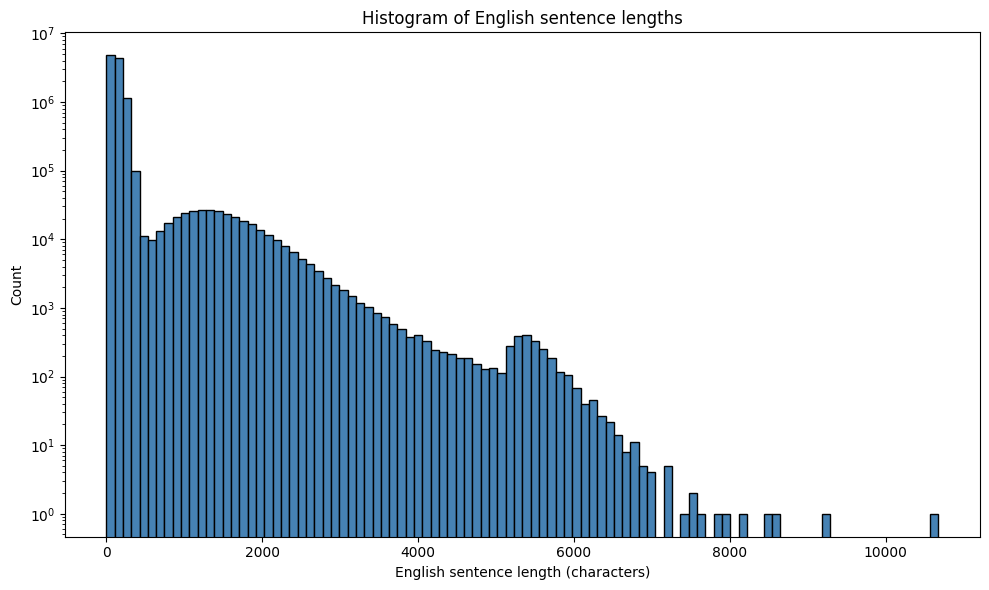

In [10]:
show_en_histo(df)

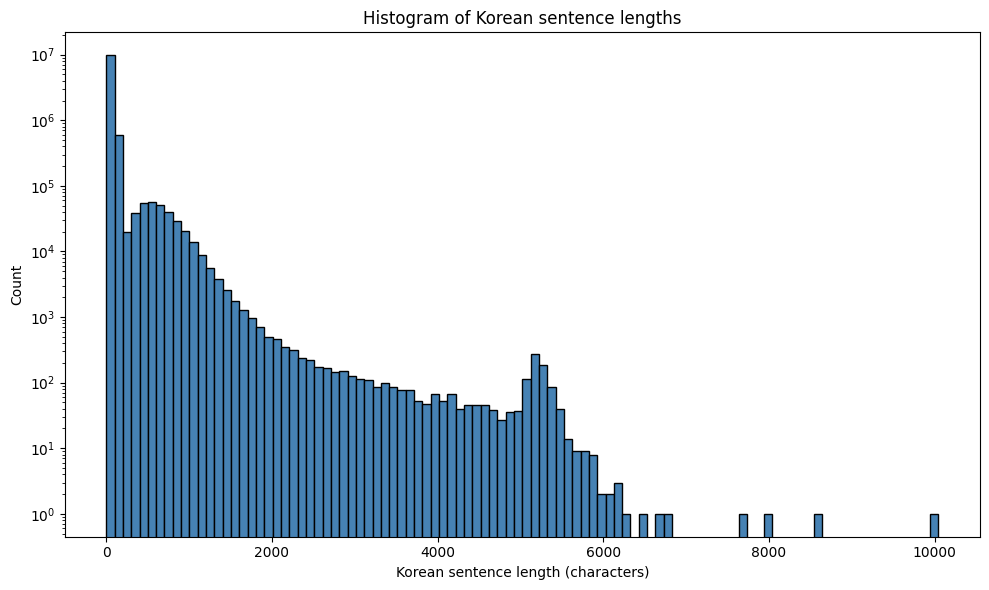

In [11]:
show_kor_histo(df)

# 지나치게 짧은 문장(토큰 수 1~5 확인), 비문자열 타입 값 제거

In [9]:
df[df["kor"].astype(str).str.len() <= 1]

,style,kor,en,domain
144599,구어체,0,0,일상/대화
317947,구어체,9,nine.,일상/대화
510628,구어체,네,Yes,일상/대화
859259,구어체,귀,Ear,일상/대화
1099463,구어체,너,You,일상/대화
7433030,문어체,ㅁ,Two years later the same authors have demonstr...,의학/보건


In [10]:
df[df["en"].astype(str).str.len() <= 1]

,style,kor,en,domain
19144,구어체,이.,Y,일상/대화
48539,구어체,엑.,X,일상/대화
72331,구어체,2.,2,일상/대화
144599,구어체,0,0,일상/대화
197701,구어체,엄청...,I,일상/대화
222588,구어체,병.,V,일상/대화
222686,구어체,아홉.,9,일상/대화
284574,구어체,여기까지 못 와?,c,일상/대화
2656284,문어체,안동 국제 탈춤 페스티벌은 보편적인 문화 유산인 '탈' 이라는 컨셉을 잘 살린 축제...,f,과학/기술/학술자료
5121326,문어체,"GO-Fe3O4는 근적외선과 고주파 교류 자기장에 의해 발열되며, 이때 발생한 열은...",-,과학/기술/학술자료


In [14]:
df[df["en"].astype(str).str.len() == 2]

,style,kor,en,domain
2750,구어체,8.,8.,일상/대화
3359,구어체,내가.,I.,일상/대화
4083,구어체,나인.,9.,일상/대화
4355,구어체,아니야.,No,일상/대화
5140,구어체,3.,3.,일상/대화
...,...,...,...,...
332695,구어체,D.,D.,일상/대화
522912,구어체,아니요,No,일상/대화
3914438,문어체/구어체 혼재,잎 무늬에 따라 가치를 매기는 엽예품으로 나뉜다.,.,문화/예술/역사
4121536,문어체/구어체 혼재,라고,as,문화/예술/역사


In [ ]:
# [7433030, 19144, 48539, 197701, 222588, 284574, 2656284, 5121326, 5241603]

### 규칙 기반 필터링

In [6]:
ds = load_dataset("csv", data_files="preprocess/10m.csv")['train']

In [9]:
def is_length_mismatch(kor, en, min_ratio=0.1, max_ratio=10.0):
    len_k = max(len(kor.strip()), 1)
    len_e = max(len(en.strip()), 1)
    ratio = len_e / len_k
    return ratio < min_ratio or ratio > max_ratio

def is_noisy_pair(kor: str, en: str) -> bool:
    # ... 으로 문장이 길어서 생략하는 경우
    if re.search(r"\.\.\.$", kor.strip()) or re.search(r"\.\.\.$", en.strip()):
        return True
    # 한국어 문장이 ㅁ, ㅏ 같이 모음이나 자음만 남고 깨진 경우
    if re.match(r"^[ㄱ-ㅎㅏ-ㅣ]\s", kor):
        return True
    if is_length_mismatch(kor, en):
        return True
    return False

def noise_example(ex):
    return is_noisy_pair(ex["kor"], ex["en"])


In [18]:
ds_noise = ds.filter(noise_example, num_proc=24)

Filter (num_proc=24):   0%|          | 0/10740846 [00:00<?, ? examples/s]

In [19]:
df_noise = ds_noise.to_pandas()

In [20]:
len(df_noise)

13605

In [ ]:
df_noise.sample(10)
# 정상 문장이 너무 많이 포함 됨

,style,kor,en,domain
3786,구어체,그때보다는 어려...,Younger than then...,일상/대화
11917,특허,"해충 방제제로서의 헤테로사이클 유도체본 발명은 화학식 (I)의 신규 화합물, 동물 ...",HETEROCYCLENE DERIVATIVES AS PEST CONTROL AGEN...,특허
4310,구어체,왜 있잖아.,You know...,일상/대화
10253,문어체/구어체 혼재,"그들의 차이에도 불구하고, 그들은 힘을합쳐 마스터 울프스의 식사 메뉴인 도우체(Do...","And despite their differences, they will have ...",문화/예술/역사
3934,구어체,"자, 그러면 .",Then...,일상/대화
4699,구어체,"야, 그래도.",But still...,일상/대화
1107,구어체,아 이거는 그냥.,This is just...,일상/대화
6981,구어체,그거 한 15년 정도...,For about 15 years...,일상/대화
0,구어체,그래서 내가 미국에서 늘 데스벨리니 자연에 가 있었구나 하는 생각이 처음으로...,"For the first time, I realized why I was alway...",일상/대화
2974,구어체,"지금, 지금 얘기...","Now, now, now...",일상/대화


In [23]:
def is_noisy_pair2(kor: str, en: str) -> bool:
    # ... 으로 문장이 길어서 생략하는 경우
    # if re.search(r"\.\.\.$", kor.strip()) or re.search(r"\.\.\.$", en.strip()):
    #     return True
    # 한국어 문장이 ㅁ, ㅏ 같이 모음이나 자음만 남고 깨진 경우
    if re.match(r"^[ㄱ-ㅎㅏ-ㅣ]\s", kor):
        return True
    if is_length_mismatch(kor, en):
        return True
    return False

def noise_example2(ex):
    return is_noisy_pair2(ex["kor"], ex["en"])


In [24]:
ds_noise2 = ds.filter(noise_example2, num_proc=24)

Filter (num_proc=24):   0%|          | 0/10740846 [00:00<?, ? examples/s]

In [25]:
df_noise2 = ds_noise2.to_pandas()

In [26]:
len(df_noise2)

117

In [27]:
df_noise2.head(100)

,style,kor,en,domain
0,구어체,주경야독.,Light alcohol during the day and strong alcoho...,일상/대화
1,구어체,풀어?,Do you want me to beat the eggs?,일상/대화
2,구어체,어울려.,I bet you would be a perfect fit for that comm...,일상/대화
3,구어체,약과다.,"Yakgwa, Korean traditional honey cookies.",일상/대화
4,구어체,체!,(All together)the House!,일상/대화
...,...,...,...,...
95,특허,수확물 수집용 수집기본 발명은 적어도 3 개의 이동 장치 (12) 및 이동 장치 (...,Collector for collecting harvested materialThe...,특허
96,특허,자재 수집 주차 시스템잔디 트랙터의 잔디 깎기 데크에서 후방 방전 촉구에 연결된 호...,Material collection parking systemA material c...,특허
97,특허,"잔디깎이용 브러시 부착물브러시 첨부 파일이 제공된다.브러시 부착 장치에있어서, 그린...",BRUSH ATTACHMENT FOR GREENS MOWERA brush attac...,특허
98,특허,위장 마당 도구발명은 야드 도구이다.위장 된 정원 도구로 구성된 장치.,Camouflage Yard ToolsThe invention is yard too...,특허


In [31]:
df_noise2_not_patent = df_noise2[df_noise2["domain"] != "특허"]

In [45]:
len(df_noise2_not_patent)

64

In [42]:
pd.set_option("display.max_colwidth", 100)

In [48]:
df_noise2_not_patent[:32]

,style,kor,en,domain
0,구어체,주경야독.,Light alcohol during the day and strong alcohol at night.,일상/대화
1,구어체,풀어?,Do you want me to beat the eggs?,일상/대화
2,구어체,어울려.,I bet you would be a perfect fit for that commercial.,일상/대화
3,구어체,약과다.,"Yakgwa, Korean traditional honey cookies.",일상/대화
4,구어체,체!,(All together)the House!,일상/대화
5,구어체,주경야독.,Light alcohol during the day and strong alcohol at night.,일상/대화
6,구어체,다야?,That's the only choreography you can do in that situation.,일상/대화
7,구어체,남남북녀.,"Nam Nam Buk Nyeo (South, North, South Korea.In the South it is the men who are handsome and in t...",일상/대화
8,구어체,좋댓구알?,"Likes comment, subscribe, and the notification bell?",일상/대화
9,구어체,금시초문.,Something never heard of (pronounced 'geumshichomun').,일상/대화


In [49]:
df_noise2_not_patent[32:64]

,style,kor,en,domain
32,구어체,동서?,He's Seong-eun's sister's husband?,일상/대화
33,구어체,수협.,National Federation of Fisheries Cooperatives.,일상/대화
34,구어체,맞춰봐.,You have to be in line with your colleagues.,일상/대화
35,구어체,냉삼은.,What about Frozen Samgyeopsal(Pork belly)?,일상/대화
36,구어체,남남?,They have nothing to do with each other?,일상/대화
37,구어체,양도설다액새깨.,"Oninons, red pepper powder, sugar, minced garlic, fish sauce and salted shrimp, and sesame salt.",일상/대화
38,구어체,청국장?,Cheonggukjang? (fermented soybean paste stew),일상/대화
39,구어체,슝슝슝슝슝슝~,Shoong shoong shoong shoong shoong shoong shoong shoong shoong shoong shoong~,일상/대화
40,구어체,잠시만 수정하겠습니다.,One of your requirements include production of digital content and publication materials across ...,일상/대화
41,구어체,정말로?,Can I really choose anything that I want?,일상/대화


풀어?	Do you want me to beat the eggs?

어울려.	I bet you would be a perfect fit for that commercial.

와 같이 한국어는 짧고 영어는 한국어에는 없는 전후 맥락이 포함되어 긴 번역 -> nosiy parallel data

금시초문.	Something never heard of (pronounced 'geumshichomun').

오빠 해.	Go ahead and do it, oppa(older brother used only by women).

감천.	Gamcehon. (The utmost sincerity touches the heavens)

과 같이 괄호속 설명이 추가된 경우도 noise

In [50]:
df[df['kor'] == "(번역 불가)"]

,style,kor,en,domain
4275420,문어체/구어체 혼재,(번역 불가),You know definitely not the same type of losing people left and right or growing up.,문화/예술/역사


In [96]:
def has_paren(s: str) -> bool:
    s = str(s)
    return ("(" in s) or (")" in s)

def is_noisy_pair3(kor: str, en: str) -> bool:
    # ... 으로 문장이 길어서 생략하는 경우
    # if re.search(r"\.\.\.$", kor.strip()) or re.search(r"\.\.\.$", en.strip()):
    #     return True
    # 한국어 문장이 ㅁ, ㅏ 같이 모음이나 자음만 남고 깨진 경우
    if re.match(r"^[ㄱ-ㅎㅏ-ㅣ]\s", kor):
        return True
    if re.match(r"^[a-zA-Z]\s", kor) and len(kor) <= 2:
        return True
    if re.match(r"^[ㄱ-ㅎㅏ-ㅣ]\s", en):
        return True
    if re.match(r"^[a-zA-Z]\s", en) and len(en) <= 2:
        return True
    if has_paren(kor) ^ has_paren(en):
        return True
    # if not has_paren(kor) and has_paren(en):
    #     return True
    # 괄호 조건은 법률 조항 문장 등에 (1) 항 등으로 정상 문장에서 많이 쓰이는 문제가 있어 조건을 좀 더 구체화할 필요가 있음
    if is_length_mismatch(kor, en):
        return True
    return False

def noise_example3(ex):
    return is_noisy_pair3(ex["kor"], ex["en"])


In [97]:
ds_noise3 = ds.filter(noise_example3, num_proc=24)

Filter (num_proc=24):   0%|          | 0/10740846 [00:00<?, ? examples/s]

In [98]:
len(ds_noise3)

762701

In [99]:
df_noise3 = ds_noise3.to_pandas()
print(len(df_noise3))

762701


In [100]:
df_noise3_not_patent = df_noise3[df_noise3["domain"] != "특허"]
print(len(df_noise3_not_patent))

713101


In [101]:
df_noise3_not_patent.sample(10)

,style,kor,en,domain
313011,문어체,"이어 김수현, 미스에이 수지, 타이니지 도희 등의 댄스트레이닝을 했던 세종대학교 석진욱 교수(실용무용전공)가 맡고 있는 댄스 중급반을 찾았다.","Afterward, he visited the middle class of dance, where Professor Seok Jin-wook of Sejong Univers...",문화/예술/역사
688953,문어체,"한편, 프라이벗 미러링 모드 하에서, 사용자는 이동 단말기(500)를 통해 다른 작업을 수행할 수 있다.","Meanwhile, under the private mirroring mode, a user may perform another task through the mobile ...",과학/기술/학술자료
683717,문어체,기 설정된 광은 기 설정된 제 1 좌표(X1Y1)에서 전반사되도록 설계된다.,The preset light is designed to be totally reflected at the preset first coordinate X1Y1.,과학/기술/학술자료
520164,문어체,"다양한 실시 예에서, 전자 장치(101)는 선호 대기 위치에 관한 정보를 획득할 수 있다.","According to various embodiments, the electronic device 101 may acquire information on preferred...",과학/기술/학술자료
235172,문어체,영국 브리스틀대학에 따르면 이 대학 지구과학 부문 마이크 벤튼 교수가 이끄는 연구팀은 고생물학과 분자발달 생물학 정보를 분석해 얻은 이런 연구결과를 과학저널 '생태 및 진화...,"In line with the University of Bristol, UK, a study team led by Professor Mike Benton of Earth S...",과학/기술/학술자료
539156,문어체,상기 블럭 수용부(581)의 상방에는 상하방향으로 관통되는 관통부(582)가 형성될 수 있다.,A through-part 582 penetrating in the vertical direction may be formed above the block accommoda...,과학/기술/학술자료
148754,문어체,"내부 카메라(122c)의 프로세서는 차량(100) 내에 탑승자에 대한 이미지를 획득하여, 탑승 인원이 몇 명인지, 탑승자가 어느 자리에 탑승하였는지 검출할 수 있다.",The processor of the internal camera 122c may acquire an image of the occupants in the vehicle 1...,과학/기술/학술자료
337423,문어체,도지사는 제2항의 기본계획에 따른 시행계획을 매년 수립하여야 하며 시·군별 시행계획 등의 추진실적을 경기도의회 해당 상임위원회에 보고 하여야 한다.,The Do governor shall annually formulate an implementation plan according to the basic plan unde...,법률/행정
496744,문어체,원격제어장치(300)는 채널 번호를 포함하는 적외선 신호를 생성하여 STB(100)로 전송할 수 있다.,The remote control device 300 may generate an infrared signal including the channel number and m...,과학/기술/학술자료
532526,문어체,운전 모드에 대한 정보(1410)는 공조 장치(1000)의 현재의 동작 상태에 대한 정보를 포함할 수 있다.,The operation mode information 1410 may include information on a current operation state of the ...,과학/기술/학술자료


In [ ]:
def is_noisy_pair4(kor: str, en: str) -> bool:
    # ... 으로 문장이 길어서 생략하는 경우
    # if re.search(r"\.\.\.$", kor.strip()) or re.search(r"\.\.\.$", en.strip()):
    #     return True
    # 한국어 문장이 ㅁ, ㅏ 같이 모음이나 자음만 남고 깨진 경우
    if re.match(r"^[ㄱ-ㅎㅏ-ㅣ]\s", kor):
        return True
    if re.match(r"^[a-zA-Z]\s", kor) and len(kor) <= 2:
        return True
    if re.match(r"^[ㄱ-ㅎㅏ-ㅣ]\s", en):
        return True
    if re.match(r"^[a-zA-Z]\s", en) and len(en) <= 2:
        return True
    # if has_paren(kor) ^ has_paren(en):
    #     return True
    # if not has_paren(kor) and has_paren(en):
    #     return True
    # 괄호 조건은 법률 조항 문장 등에 (1) 항 등으로 정상 문장에서 많이 쓰이는 문제가 있어 조건을 좀 더 구체화할 필요가 있음
    if is_length_mismatch(kor, en):
        return True
    return False

def noise_example4(ex):
    return is_noisy_pair4(ex["kor"], ex["en"])


In [103]:
ds_noise4 = ds.filter(noise_example4, num_proc=24)
df_noise4 = ds_noise4.to_pandas()
print(len(df_noise4))

Filter (num_proc=24):   0%|          | 0/10740846 [00:00<?, ? examples/s]

120


In [104]:
df_noise4_not_patent = df_noise4[df_noise4["domain"] != "특허"]
print(len(df_noise4_not_patent))

67


In [105]:
df_noise4_not_patent[:35]

,style,kor,en,domain
0,구어체,주경야독.,Light alcohol during the day and strong alcohol at night.,일상/대화
1,구어체,풀어?,Do you want me to beat the eggs?,일상/대화
2,구어체,어울려.,I bet you would be a perfect fit for that commercial.,일상/대화
3,구어체,약과다.,"Yakgwa, Korean traditional honey cookies.",일상/대화
4,구어체,체!,(All together)the House!,일상/대화
5,구어체,주경야독.,Light alcohol during the day and strong alcohol at night.,일상/대화
6,구어체,다야?,That's the only choreography you can do in that situation.,일상/대화
7,구어체,남남북녀.,"Nam Nam Buk Nyeo (South, North, South Korea.In the South it is the men who are handsome and in t...",일상/대화
8,구어체,좋댓구알?,"Likes comment, subscribe, and the notification bell?",일상/대화
9,구어체,금시초문.,Something never heard of (pronounced 'geumshichomun').,일상/대화


In [106]:
df_noise4_not_patent[35:]

,style,kor,en,domain
35,구어체,냉삼은.,What about Frozen Samgyeopsal(Pork belly)?,일상/대화
36,구어체,남남?,They have nothing to do with each other?,일상/대화
37,구어체,양도설다액새깨.,"Oninons, red pepper powder, sugar, minced garlic, fish sauce and salted shrimp, and sesame salt.",일상/대화
38,구어체,청국장?,Cheonggukjang? (fermented soybean paste stew),일상/대화
39,구어체,슝슝슝슝슝슝~,Shoong shoong shoong shoong shoong shoong shoong shoong shoong shoong shoong~,일상/대화
40,구어체,잠시만 수정하겠습니다.,One of your requirements include production of digital content and publication materials across ...,일상/대화
41,구어체,정말로?,Can I really choose anything that I want?,일상/대화
42,구어체,난 가봤어!,"I've been to some of the best cities in the world, so I know which is the very best.",일상/대화
43,문어체,안동 국제 탈춤 페스티벌은 보편적인 문화 유산인 '탈' 이라는 컨셉을 잘 살린 축제 기획으로 평가되고 있다.,f,과학/기술/학술자료
44,문어체,"파리의 시위대는 깃발,플래카드를 흔들며 시청에서 가르니에 오페라하우스까지 행진했다.",",162,000 for London's Flying Gorilla Performance's Great Smelly Feet Dance and Unbelievable Four...",과학/기술/학술자료


In [14]:


def is_noisy_pair5(kor: str, en: str) -> bool:
    # ... 으로 문장이 길어서 생략하는 경우
    # if re.search(r"\.\.\.$", kor.strip()) or re.search(r"\.\.\.$", en.strip()):
    #     return True
    # 한국어 문장이 ㅁ, ㅏ 같이 모음이나 자음만 남고 깨진 경우
    if re.match(r"^[ㄱ-ㅎㅏ-ㅣ]\s", kor) and len(kor) <= 2:
        return True
    if re.match(r"^[a-zA-Z]\s", kor) and len(kor) <= 2:
        return True
    if re.match(r"^[ㄱ-ㅎㅏ-ㅣ]\s", en) and len(en) <= 2:
        return True
    if re.match(r"^[a-zA-Z]\s", en) and len(en) <= 2:
        return True
    # if has_paren(kor) ^ has_paren(en):
    #     return True
    # if not has_paren(kor) and has_paren(en):
    #     return True
    # 괄호 조건은 법률 조항 문장 등에 (1) 항 등으로 정상 문장에서 많이 쓰이는 문제가 있어 조건을 좀 더 구체화할 필요가 있음
    if is_length_mismatch(kor, en, 0.2, 5.0):
        return True
    return False

def noise_example5(ex):
    return is_noisy_pair5(ex["kor"], ex["en"])


In [15]:
ds_noise5 = ds.filter(noise_example5, num_proc=24)
df_noise5 = ds_noise5.to_pandas()
print(len(df_noise5))

Filter (num_proc=24):   0%|          | 0/10740846 [00:00<?, ? examples/s]

4880


In [16]:
df_noise5_not_patent = df_noise5[df_noise5["domain"] != "특허"]
print(len(df_noise5_not_patent))

4350


In [19]:
df_noise5_not_patent.sample(10)

,style,kor,en,domain
1296,구어체,부부의 백년해로.,The married growing old together for 100 years.,일상/대화
2252,구어체,먹다가 찍은 것 같아.,This looks like they took a picture during the middle of their mealtime,일상/대화
3048,구어체,뭐 사려고요?,What kinds of things are you going to get?,일상/대화
1057,구어체,아 가자.,Come on. Come one. Rock-paper-scissors,일상/대화
1875,구어체,바뀐 만두죠?,"It's the changed version of the dumpling, right?",일상/대화
749,구어체,자만추~,'Jamanchu'(pursuit for natural dating),일상/대화
3285,구어체,큰 문제는 없습니다.,I would like to assure you that there is no major issue.,일상/대화
31,구어체,가사.,Domestic affairs.,일상/대화
2453,구어체,영화관에 갈까요?,That is because we are the leading drama streaming service in Asia!,일상/대화
3292,구어체,대신 철물점에서 얻죠.,"Instead, these materials will be obtained from the hardware store.",일상/대화


In [20]:
df_noise5_informal = df_noise5_not_patent[df_noise5_not_patent["domain"] == "일상/대화"]
len(df_noise5_informal)

3415

In [25]:
df_noise5_informal.sample(10)

,style,kor,en,domain
1929,구어체,오면 대상.,"If he comes, he's the grand prize winner.",일상/대화
769,구어체,집구석에.,In the corner of the house.,일상/대화
1870,구어체,올려줄까.,Do you want me to put it up?,일상/대화
1555,구어체,나와 계셨어요?,"Where are you standing outside, waiting for me?",일상/대화
1099,구어체,오해였어?,Was it a misunderstanding?,일상/대화
1807,구어체,사공이 많으면 배가 산으로 간다.,"If there are many sailors, the boat goes to the mountains. (Too many cooks spoil the broth.)",일상/대화
911,구어체,사람 많은 게 좋네.,It's an advantage to have a lot of people in your agency.,일상/대화
3023,구어체,"맞아, 곧 끝날 거야.","That's so true, and because of that we're almost done with it.",일상/대화
2111,구어체,동생.,Younger sibling.,일상/대화
1501,구어체,죽여?,Should I kill him?,일상/대화


In [26]:
def has_paren(s: str) -> bool:
    s = str(s)
    return ("(" in s) or (")" in s)

In [35]:
mask = df_noise5_informal["en"].astype(str).str.contains(r"\(", na=False)

df_noise5_informal2 = df_noise5_informal[mask]
len(df_noise5_informal2)

102

In [38]:
df_noise5_informal2.sample(10)

,style,kor,en,domain
939,구어체,일사천리.,Il Sa Cheol Li (Dashing fow of torrents).,일상/대화
926,구어체,정답 금상천화!,Answer. Frosting on the cake (pronounced 'geumsangcheonhwa')!,일상/대화
870,구어체,오빠요?,Oppa? (Older brother),일상/대화
1893,구어체,반미.,Banh-mi (sandwich).,일상/대화
1029,구어체,감천.,Gamcehon. (The utmost sincerity touches the heavens),일상/대화
1818,구어체,백중초생이 뭐지?,"What's ""repose of the death (15th), new life""?",일상/대화
243,구어체,숍이 같대.,Saying they go to the same shop (beaty salon).,일상/대화
672,구어체,나만 봐.,'Naman bwa (Look at me only)'.,일상/대화
1070,구어체,최루탄?,Choirutan (Tear Bomb)?,일상/대화
994,구어체,속 차려라.,(Wake up) and smell the coffee.,일상/대화


일상/대화 일경우 () 안에 추가 주석이 달린 경우 주석 제거 or 데이터 제거

- 'Naman bwa (Look at me only)'. 
- Banh-mi (sandwich)
- Oppa? (Older brother)	
- Choirutan (Tear Bomb)?

== 데이터 제거 (단순히 발음을 영어로 하고 ()안에 뜻을 번역한 것을 넣은 데이터들이 보이므로)

In [39]:
mask2 = df_noise5_informal["kor"].astype(str).str.contains(r"\(", na=False)

df_noise5_informal3 = df_noise5_informal[mask2]
len(df_noise5_informal3)

0

In [40]:
df_noise5_informal4 = df_noise5_not_patent[df_noise5_not_patent["style"] == "구어체"]
len(df_noise5_informal4)

3415

In [41]:
df = ds.to_pandas()

In [42]:
len(df[df["domain"] == "일상/대화"])

2938318

In [43]:
len(df[df["style"] == "구어체"])

2938318

### 일상/대화 아닌 doamin에서 비율 이상한 문장 제거, 일상/대화 domain에 영어에 ()로 주석이나 발음(번역)인 형태 제거

In [7]:
def has_paren(s: str) -> bool:
    s = str(s)
    return ("(" in s) or (")" in s)

def is_length_mismatch(kor, en, min_ratio=0.1, max_ratio=10.0):
    len_k = max(len(kor.strip()), 1)
    len_e = max(len(en.strip()), 1)
    ratio = len_e / len_k
    return ratio < min_ratio or ratio > max_ratio


def is_noisy_pair(kor: str, en: str, domain: str) -> bool:
    # ... 으로 문장이 길어서 생략하는 경우
    # if re.search(r"\.\.\.$", kor.strip()) or re.search(r"\.\.\.$", en.strip()):
    #     return True
    # 한국어 문장이 ㅁ, ㅏ 같이 모음이나 자음만 남고 깨진 경우
    if re.match(r"^[ㄱ-ㅎㅏ-ㅣ]\s", kor) and len(kor) <= 2:
        return True
    if re.match(r"^[a-zA-Z]\s", kor) and len(kor) <= 2:
        return True
    if re.match(r"^[ㄱ-ㅎㅏ-ㅣ]\s", en) and len(en) <= 2:
        return True
    if re.match(r"^[a-zA-Z]\s", en) and len(en) <= 2:
        return True
    if domain != "일상/대화" and is_length_mismatch(kor, en, 0.2, 5.0):
        return True
    
    if domain == "일상/대화" and is_length_mismatch(kor, en, 0.1, 10.0):
        return True
    
    if domain == "일상/대화" and has_paren(en) and not has_paren(kor):
        return True

    return False

def noise_example(ex):
    return is_noisy_pair(ex["kor"], ex["en"], ex["domain"])

def noise_example_filter(ex):
    return not is_noisy_pair(ex["kor"], ex["en"], ex["domain"])


In [68]:
ds_noise = ds.filter(noise_example, num_proc=24)
df_noise = ds_noise.to_pandas()
print(len(df_noise))

Filter (num_proc=24):   0%|          | 0/10740846 [00:00<?, ? examples/s]

2257


In [69]:
df_noise_informal = df_noise[df_noise["domain"] == "일상/대화"]
len(df_noise_informal)

792

In [71]:
df_noise_informal.sample(20)

,style,kor,en,domain
6,구어체,강강술래.,(All) Ganggangsullae.,일상/대화
64,구어체,샵이 같다고요?,We go to the same shop (beauty salon)?,일상/대화
114,구어체,하하하~,(Laughs),일상/대화
156,구어체,부르르르르르르.,(sound),일상/대화
360,구어체,잡채.,Stir-fried glass noodles and vegetables.,일상/대화
364,구어체,제일 원픽이었던 반미 해보겠습니다.,"I'll try banh-mi(sandwich), which was my fist choice.",일상/대화
2105,구어체,인공지능의 급속한 발전은 노동 계급 대부분의 재정적 문제로 여겨진다.,The rapid development of AI (Artificial Intelligence) is considered as a financial problem for most of the working class.,일상/대화
287,구어체,아하하하하~,(Laughs),일상/대화
349,구어체,저는 반미가 딱 눈에 띄었습니다.,I noticed the Banh-mi(sandwich) right away.,일상/대화
89,구어체,샵?,Shop (Beauty salon)?,일상/대화


In [72]:
df_noise_not_patent_nor_informal = df_noise[(df_noise["domain"] != "일상/대화") & (df_noise["domain"] != "특허")]
len(df_noise_not_patent_nor_informal)

935

In [64]:
pd.set_option("display.max_colwidth", 200)

In [65]:
df_noise_not_patent_nor_informal.sample(20)

,style,kor,en,domain
1532,문어체,"같은 날 통계청 국감에선 가계동향조사 결과와 통계청장 경질 문제가, 16일 한국재정정보원 국감에선 심재철 한국당 의원의 비인가 재정정보 유출 논란이 화두다.","On the same day, at the parliamentary inspection of the administration of the National Statistical Office, the issue of the results of the household trend survey and the replacement of the head of...",뉴스/시사
954,문어체/구어체 혼재,국화만!,You know just Daisies!,문화/예술/역사
648,문어체,물개섬 주변은 백상아리가 수면 위로 솟구쳐 오르며 케이프 물개를 잡는 곳으로 유명하다.,"The remarks in question were intended to encourage students to focus on their studies because the issue of climate change is one that politicians should address, but some political parties, groups...",과학/기술/학술자료
1520,문어체,sevrel,"BBB1 was in charge of the implementation, while the construction of the BBB2 and the trust company BBB3 were in charge.",뉴스/시사
1752,문어체,신임 농협중앙회 충남지역본부장에 길정섭 농협중앙회 상호금융증권운용부 부장이 내정됐다.,"Gil Jeong-seop, head of the union finance securities management department of the National Agricultural Cooperative Federation, has been appointed as the new head of the Chungnam regional headquar...",금융/경제
1860,문어체,총론과 각론 개발의 시간적 차이를 두거나 동시에 개발하는 것이다.,It is to develop at the same time as the general thesis or at the same time as the time difference between the development of the general thesis and the development of the individual thesis.,과학/기술/학술자료
1654,문어체,이 사건 공소사실중 공문서부정행사의 점은 무죄.,"Of the criminal facts subject to judgment of this case, as to the charge of misconducting official documents, [the Defendant] is found not guilty.",과학/기술/학술자료
1717,문어체/구어체 혼재,백령도의 메뉴가 많지는 않지만 '산 낙지비빔밥'은 꼭 추천하고 싶다.,"There are not many menus on Baengnyeongdo Island, but I would definitely recommend Raw Octopus bibimbap (steamed rice served with vegetables and sometimes meat to mix in the bowl at the table).",문화/예술/역사
1554,문어체,광촉매의 코팅된 유리섬유직물에 대한 항균성 및 VOC 분해 특성을 알아보았다.,"According to the Korea Institute of Science and Technology Planning and Evaluation in 2020, the necessity of related technology development was once again pointed out, and as a result, a large-sca...",과학/기술/학술자료
930,문어체/구어체 혼재,해치 아시죠? 해태.,"You know the haechi, right? Mythical unicorn lion, Haetae.",문화/예술/역사


In [66]:
df_noise[df_noise["en"] == "f"]

,style,kor,en,domain
580,문어체,안동 국제 탈춤 페스티벌은 보편적인 문화 유산인 '탈' 이라는 컨셉을 잘 살린 축제 기획으로 평가되고 있다.,f,과학/기술/학술자료


In [8]:
ds_filtered = ds.filter(noise_example_filter, num_proc=24)

In [9]:
ds_filtered.to_csv("preprocess/10m_filtered.csv")

Creating CSV from Arrow format:   0%|          | 0/10739 [00:00<?, ?ba/s]

4124458699

In [10]:
df_filtered = pd.read_csv("preprocess/10m_filtered.csv")
len(df_filtered)

10738589

In [12]:
df_filtered[df_filtered["kor"].astype(str).str.len() <= 1]

,style,kor,en,domain
144371,구어체,0,0,일상/대화
317536,구어체,9,nine.,일상/대화
510157,구어체,네,Yes,일상/대화
858756,구어체,귀,Ear,일상/대화
1098916,구어체,너,You,일상/대화


In [17]:
en_short = df_filtered[df_filtered["en"].astype(str).str.len() <= 2]
len(en_short)

190

In [18]:
en_short[:30]

,style,kor,en,domain
2740,구어체,8.,8.,일상/대화
3349,구어체,내가.,I.,일상/대화
4072,구어체,나인.,9.,일상/대화
4344,구어체,아니야.,No,일상/대화
5127,구어체,3.,3.,일상/대화
5784,구어체,만약에.,If,일상/대화
7927,구어체,내가.,I.,일상/대화
11395,구어체,9?,9?,일상/대화
11699,구어체,내가.,I…,일상/대화
12723,구어체,6!,6!,일상/대화


In [19]:
en_short[30:60]

,style,kor,en,domain
42479,구어체,0?,0?,일상/대화
42770,구어체,95,95,일상/대화
44619,구어체,M.,M.,일상/대화
46711,구어체,T.,T.,일상/대화
48465,구어체,엑.,X,일상/대화
48852,구어체,제가.,I.,일상/대화
50745,구어체,L.,L.,일상/대화
50996,구어체,H.,H.,일상/대화
53083,구어체,우.,U.,일상/대화
53715,구어체,V?,V?,일상/대화


In [20]:
en_short[60:90]

,style,kor,en,domain
75802,구어체,6!,6!,일상/대화
76724,구어체,6.,6.,일상/대화
77165,구어체,5!,5!,일상/대화
78752,구어체,2번.,2.,일상/대화
79511,구어체,2.,2.,일상/대화
80289,구어체,3!,3!,일상/대화
80517,구어체,이~,I~,일상/대화
80926,구어체,P.,P.,일상/대화
81107,구어체,4!,4!,일상/대화
81928,구어체,1!,1!,일상/대화


In [21]:
en_short[90:120]

,style,kor,en,domain
98923,구어체,가다.,Go,일상/대화
98936,구어체,2개요.,2.,일상/대화
102927,구어체,"아, 참.",Oh,일상/대화
107959,구어체,U.,U.,일상/대화
107964,구어체,9개?,9?,일상/대화
110973,구어체,아니요 아니고 그냥.,No,일상/대화
113161,구어체,5번.,5.,일상/대화
113954,구어체,셋!,3!,일상/대화
114385,구어체,B!,B!,일상/대화
114413,구어체,T.,T.,일상/대화


In [22]:
en_short[120:150]

,style,kor,en,domain
139359,구어체,칠곱이.,7.,일상/대화
141927,구어체,9개요.,9.,일상/대화
144160,구어체,6번.,6.,일상/대화
144371,구어체,0,0,일상/대화
147990,구어체,9!,9!,일상/대화
151543,구어체,I.,I.,일상/대화
153808,구어체,4!,4!,일상/대화
155464,구어체,6번!,6!,일상/대화
155619,구어체,A.,A.,일상/대화
159666,구어체,오빠가 제가.,I…,일상/대화


In [23]:
en_short[150:]

,style,kor,en,domain
222271,구어체,병.,V,일상/대화
222369,구어체,아홉.,9,일상/대화
229744,구어체,엑스.,X.,일상/대화
230386,구어체,50,50,일상/대화
235383,구어체,서른다섯.,35,일상/대화
236868,구어체,스물여덟.,28,일상/대화
237628,구어체,제.,My,일상/대화
240544,구어체,5개요?,5?,일상/대화
242070,구어체,비.,V.,일상/대화
243216,구어체,트.,T.,일상/대화


In [31]:
# 144371, 317536, 13865, 17609, 19113, 27753, 40162, 42210, 48465, 53083, 63904, 68370, 80517, 85243, 110973, 128119, 139359, 159666, 160514, 174375, 186757, 187431, 197410, 210167, 217048, 222271, 237628, 243216, 259222, 263853, 268743, 274168, 276300, 284193, 287864, 291216, 296778, 318661, 331672, 4120616, 4727164
bad_indices = [144371, 317536, 13865, 17609, 19113, 27753, 40162, 42210, 48465, 53083, 63904, 68370, 80517, 85243, 110973, 128119, 139359, 159666, 160514, 174375, 186757, 187431, 197410, 210167, 217048, 222271, 237628, 243216, 259222, 263853, 268743, 274168, 276300, 284193, 287864, 291216, 296778, 318661, 331672, 4120616, 4727164]
df_filtered = df_filtered.drop(bad_indices).reset_index(drop=True)

In [33]:
df_filtered.to_csv("preprocess/10m_filtered2.csv", index=False)

In [36]:
df_filtered[(df_filtered["en"] == "en") & (df_filtered["kor"] == "감수")]

,style,kor,en,domain


(함께) 있으면 제거

시작

시작.

미

미!

와 같은 경우 중복으로 취급하고 삭제?

# 두 데이터셋 분석 및 비교

# 특허 분류 제거

# 10m 데이터셋에서 AI HUB 한국어-영어 번역(병렬) 말뭉치 데이터셋 테스트 스플릿 제거